# 06 — Model Evaluation, Temporal Model (RetentionIQ)

Honest evaluation of the **temporal** churn model (leakage fixed), with a before/after against the old snapshot setup. Works whether or not `is_churned` is in the feature table: with it, metrics are recomputed live; without it, they are read from the saved training metrics.

In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, precision_score, recall_score)
import xgboost as xgb

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA = ROOT / "data"

meta  = json.load(open(DATA / "models" / "churn_xgboost_temporal_metrics.json"))
FEATS = meta["feature_cols"]
WINDOW = meta["churn_window_days"]

df = pd.read_parquet(DATA / "features" / "feature_table_temporal.parquet")
HAS_LABEL = "is_churned" in df.columns

print(f"temporal table: {len(df):,} customers | {len(FEATS)} features | window = {WINDOW} days")
print(f"split_date = {meta['split_date'][:10]}   max_date = {meta['max_date'][:10]}")
print("is_churned in table:", HAS_LABEL,
      "(live evaluation)" if HAS_LABEL else "(reading saved metrics; re-export with is_churned for live eval)")

temporal table: 395,612 customers | 43 features | window = 299 days
split_date = 2025-05-19   max_date = 2026-03-14
is_churned in table: True (live evaluation)


## 1. The leakage, before and after

Two ways to define the churn label:

- **Snapshot (old):** churned if `days_since_last_order > 299`, measured today. This makes `days_since` the label thresholded, so it predicts itself.
- **Temporal (new):** churned if there was no purchase in the 299 days *after* a cutoff. `days_since` is measured at the cutoff, so it becomes a real (weak) feature, not the answer.

In [9]:
# BEFORE: snapshot label, days_since predicts itself
snap_path = DATA / "features" / "feature_table.parquet"
if snap_path.exists():
    snap = pd.read_parquet(snap_path)
    snap.columns = [c.lower() for c in snap.columns]
    y_snap = (snap["days_since_last_order"] > WINDOW).astype(int)
    auc_snap_leak = roc_auc_score(y_snap, snap["days_since_last_order"])
    print(f"snapshot label churn rate: {y_snap.mean():.3f}")
    print(f"AUROC of days_since_last_order ALONE vs the snapshot label: {auc_snap_leak:.4f}")
    print("~1.0 means the feature IS the label. That is the leakage we had.")
else:
    auc_snap_leak = 1.0
    print("feature_table.parquet not found; skipping the snapshot demo.")

snapshot label churn rate: 0.489
AUROC of days_since_last_order ALONE vs the snapshot label: 1.0000
~1.0 means the feature IS the label. That is the leakage we had.


In [10]:
# AFTER: temporal label, the same feature is no longer the answer
if HAS_LABEL:
    y = df["is_churned"].astype(int)
    auc_temp_dsl = roc_auc_score(y, df["days_since_last_order"])
    print(f"temporal label churn rate: {y.mean():.3f}")
    print(f"AUROC of days_since_last_order ALONE vs the temporal label: {auc_temp_dsl:.4f}")
    print("Far from 1.0: the feature that leaked before is now just a weak signal. Leak fixed.")
else:
    auc_temp_dsl = None
    print("is_churned not in the table, so this can't be computed live.")
    print("Proxy below (SHAP): days_since is no longer the top driver. Under leakage it would dominate.")

temporal label churn rate: 0.942
AUROC of days_since_last_order ALONE vs the temporal label: 0.6418
Far from 1.0: the feature that leaked before is now just a weak signal. Leak fixed.


## 2. Temporal model — honest performance

The number to quote is the **5-fold CV AUROC**. The base churn rate is ~0.94, so AUPRC sits high by construction; read it as a modest lift over that baseline, not as a strong number.

HEADLINE (5-fold CV, the honest held-out number):
  AUROC = 0.6792 +/- 0.0037
  single test-split AUROC = 0.6862 | AUPRC = 0.9688
  base churn rate ~ 0.94 (AUPRC baseline)

Consistency check on the FULL table (in-sample, slightly optimistic):
  AUROC = 0.6927 | AUPRC = 0.9701

At the model operating threshold (0.08):
confusion matrix [rows=actual, cols=pred]:
 [[   932  22134]
 [   534 372012]]
precision: 0.944 | recall: 0.999


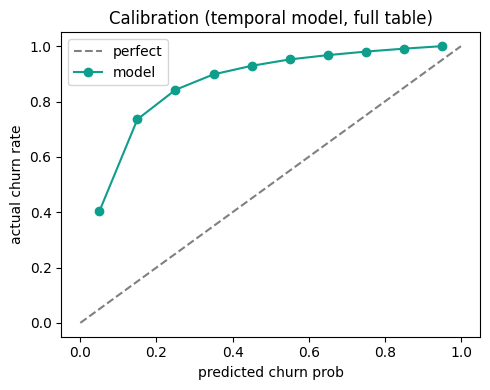

In [11]:
bst = xgb.Booster(); bst.load_model(str(DATA / "models" / "churn_xgboost_temporal.json"))
proba = bst.predict(xgb.DMatrix(df[FEATS].astype(float), feature_names=FEATS))

print("HEADLINE (5-fold CV, the honest held-out number):")
print(f"  AUROC = {meta['cv5_auroc_mean']:.4f} +/- {meta['cv5_auroc_std']:.4f}")
print(f"  single test-split AUROC = {meta['test_auroc']:.4f} | AUPRC = {meta['test_auprc']:.4f}")
print(f"  base churn rate ~ {meta['train_churn_rate']:.2f} (AUPRC baseline)")
print()

if HAS_LABEL:
    y = df["is_churned"].astype(int)
    print(f"Consistency check on the FULL table (in-sample, slightly optimistic):")
    print(f"  AUROC = {roc_auc_score(y, proba):.4f} | AUPRC = {average_precision_score(y, proba):.4f}")
    thr = meta.get("best_f1_threshold", 0.5)
    pred = (proba >= thr).astype(int)
    print(f"\nAt the model operating threshold ({thr}):")
    print("confusion matrix [rows=actual, cols=pred]:\n", confusion_matrix(y, pred))
    print(f"precision: {precision_score(y, pred, zero_division=0):.3f} | recall: {recall_score(y, pred, zero_division=0):.3f}")
    buckets = pd.cut(proba, np.linspace(0, 1, 11))
    calib = pd.DataFrame({"y": y.values, "b": buckets}).groupby("b", observed=True)["y"].mean()
    mids = [iv.mid for iv in calib.index]
    plt.figure(figsize=(5, 4))
    plt.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
    plt.plot(mids, calib.values, "o-", color="#0F9D8C", label="model")
    plt.xlabel("predicted churn prob"); plt.ylabel("actual churn rate")
    plt.title("Calibration (temporal model, full table)"); plt.legend(); plt.tight_layout(); plt.show()
else:
    print("Live AUROC / confusion / calibration need is_churned in the table.")
    print("Re-export from notebook 04 with:")
    print("  df[['customer_id','is_churned'] + FEATURE_COLS].to_parquet('../data/features/feature_table_temporal.parquet', index=False)")

## 3. What drives the temporal model

From the SHAP ranking saved at training time (no SHAP recompute needed, so no library version issues). The point: `days_since_last_order` is no longer the top driver.

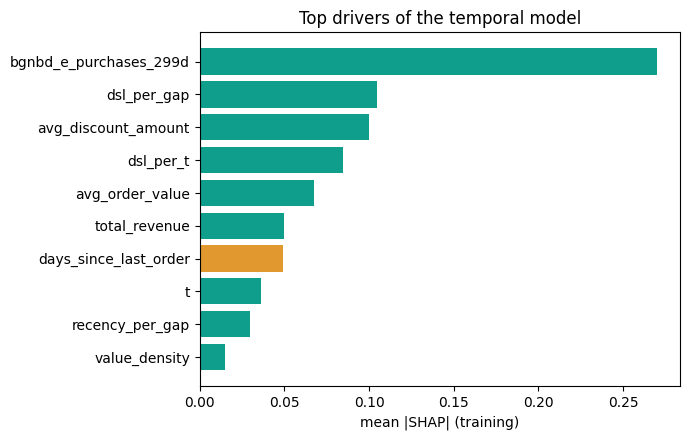

Top driver: bgnbd_e_purchases_299d
days_since_last_order rank: #7 of top 10


In [12]:
shap_rank = pd.Series(meta["shap_top10_mean_abs"]).sort_values()
colors = ["#E0982F" if f == "days_since_last_order" else "#0F9D8C" for f in shap_rank.index]
plt.figure(figsize=(7, 4.5))
plt.barh(shap_rank.index, shap_rank.values, color=colors)
plt.xlabel("mean |SHAP| (training)"); plt.title("Top drivers of the temporal model")
plt.tight_layout(); plt.show()

ranked = list(pd.Series(meta["shap_top10_mean_abs"]).sort_values(ascending=False).index)
print("Top driver:", ranked[0])
if "days_since_last_order" in ranked:
    print(f"days_since_last_order rank: #{ranked.index('days_since_last_order')+1} of top 10")
else:
    print("days_since_last_order is not in the top 10 drivers at all.")

## 4. CLV — sanity checks

BG/NBD params: {'r': 0.03526398143992196, 'alpha': 6.761056378817459, 'a': 0.5015829208403754, 'b': 0.20943229020517853}
Gamma-Gamma params: {'p': 4.081664320512658, 'q': 0.43483558734109745, 'v': 3.8699695453012266}

scored customers: 395,612
share with CLV = 0 (one-time buyers): 88.4%
count    395612.00
mean          6.83
std          50.82
min           0.00
25%           0.00
50%           0.00
75%           0.00
max        8391.85
Name: predicted_clv, dtype: float64


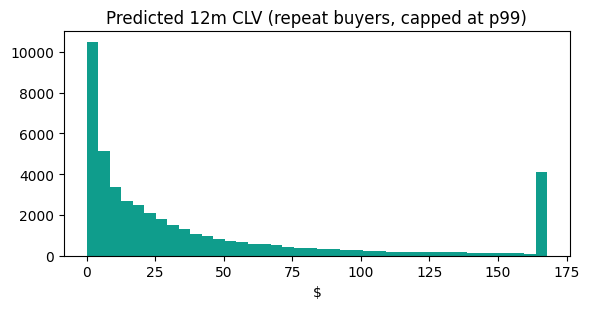

In [13]:
bg = json.load(open(DATA / "models" / "clv_bgnbd_params.json"))
gg = json.load(open(DATA / "models" / "clv_gamma_gamma_params.json"))
print("BG/NBD params:", bg)
print("Gamma-Gamma params:", gg)

scored_path = DATA / "scored" / "customer_scores.parquet"
if scored_path.exists():
    sc = pd.read_parquet(scored_path)
    zero = (sc["predicted_clv"] == 0).mean()
    print(f"\nscored customers: {len(sc):,}")
    print(f"share with CLV = 0 (one-time buyers): {zero*100:.1f}%")
    print(sc["predicted_clv"].describe().round(2))
    plt.figure(figsize=(6, 3.2))
    plt.hist(sc.loc[sc["predicted_clv"] > 0, "predicted_clv"].clip(upper=sc["predicted_clv"].quantile(.99)), bins=40, color="#0F9D8C")
    plt.title("Predicted 12m CLV (repeat buyers, capped at p99)"); plt.xlabel("$"); plt.tight_layout(); plt.show()
else:
    print("Run score_customers.py first to evaluate the scored CLV output.")

## 5. Segmentation — separation check

In [14]:
seg_path = DATA / "models" / "segmentation_kmeans.json"
if seg_path.exists():
    seg = json.load(open(seg_path))
    print(f"k = {seg['k']} | silhouette = {seg['silhouette']}")
    print("segment names:", seg["segment_names"])
    segs = pd.read_parquet(DATA / "scored" / "customer_segments.parquet")
    print("\nsegment sizes:")
    print(segs["segment"].value_counts())
else:
    print("Run 05_segmentation_temporal.ipynb first.")

k = 6 | silhouette = 0.4716
segment names: {'0': 'Recent one-timers', '1': 'High returns', '2': 'Near-zero value', '3': 'Repeat buyers', '4': 'Low value', '5': 'Dormant one-timers'}

segment sizes:
segment
Recent one-timers     186270
Dormant one-timers    127897
Repeat buyers          44228
High returns           16270
Low value              15178
Near-zero value         5769
Name: count, dtype: int64


## Bottom line (say this out loud in the demo)

- The old setup leaked: `days_since` alone scored ~1.0 AUROC against the snapshot label, because the label *was* that feature thresholded.
- The temporal model fixes it: proper future-window label, honest **AUROC ~0.68 (5-fold CV 0.679 +/- 0.004)**, and `days_since` is no longer the top driver.
- 0.68 with no leakage is worth more than 0.99 that just reads the answer. On an 88%-one-timer base, customer-level churn is genuinely hard.